In [163]:
import logomaker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# data = pd.read_csv(f'{OUTPUT_DIR}/mpnn_results.csv')

In [164]:
import glob
results_file = glob.glob('/clusterfs/nilah/sergio/RFdifussion/outputs/*/*.csv')
print(len(results_file))

4


In [165]:
import pandas as pd
import os

def aggregate_results(results_files, run_id_level=-2, extra_columns=None):
    """
    Aggregate CSV files into a single DataFrame with run identifiers.
    
    Args:
        results_files (list): List of paths to CSV files.
        run_id_level (int): Directory level to extract run ID (e.g., -2 for parent of filename).
        extra_columns (dict): Optional dictionary of column_name: lambda_function to add metadata.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame with run IDs and optional columns.
    """
    if not results_files:
        print("Warning: No files provided.")
        return pd.DataFrame()

    dfs = []
    for file_path in results_files:
        # try:
        # Read CSV
        tmp = pd.read_csv(file_path)
        
        # Extract run ID from path
        run_id = os.path.split(os.path.dirname(file_path))[run_id_level]
        tmp['RUN'] = run_id
        
        # Add optional columns
        # if extra_columns:
        #     for col_name, func in extra_columns.items():
        #         tmp[col_name] = func(file_path)
        
        dfs.append(tmp)
        print(f"Processed: {file_path}")
    


    # Concatenate all DataFrames
    if dfs:
        results = pd.concat(dfs, axis=0 )# , ignore_index=True)
        print(f"Aggregated {len(dfs)} files into DataFrame with {len(results)} rows.")
        return results
    else:
        print("No valid files processed.")
        return pd.DataFrame()

# Example usage for RFdiffusion results
# results_dir = "/clusterfs/nilah/sergio/RFdifussion/outputs/EPITOPE_SERIES_20250416/*/af2.csv"
results_files = glob.glob('/clusterfs/nilah/sergio/RFdifussion/outputs/*/*.csv')

# # Define extra columns (e.g., extract contigs, iterations, num_seqs from run name)
# extra_columns = {
#     'contigs': lambda x: x.split('/')[-3].split('_C')[1].split('_I')[0],
#     'iterations': lambda x: x.split('_I')[1].split('_NS')[0],
#     'num_seqs': lambda x: x.split('_NS')[1].split('_')[0]
# }

# Aggregate results
results = aggregate_results(results_files, run_id_level=-2) #, extra_columns=extra_columns)

Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD_EPITOPE_v0_20250416_CA:9_I200_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD_EPITOPE_v0_20250416_CA:10_I200_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD_EPITOPE_v0_20250416_CA:8_I200_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD_EPITOPE_v0_20250416_CA:11_I200_NS32/mpnn_results.csv
Aggregated 4 files into DataFrame with 128 rows.


array([[<Axes: title={'center': 'plddt'}>]], dtype=object)

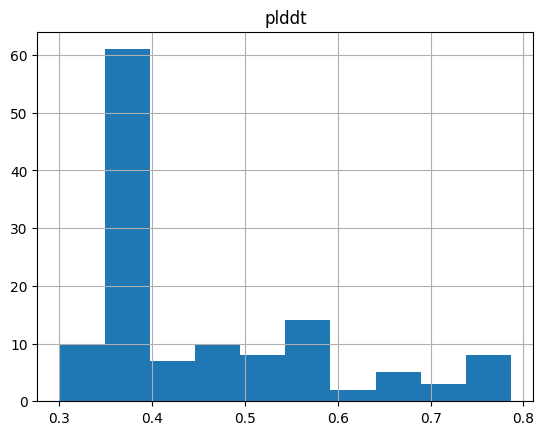

In [166]:
results.hist('plddt')

array([[<Axes: title={'center': 'rmsd'}>]], dtype=object)

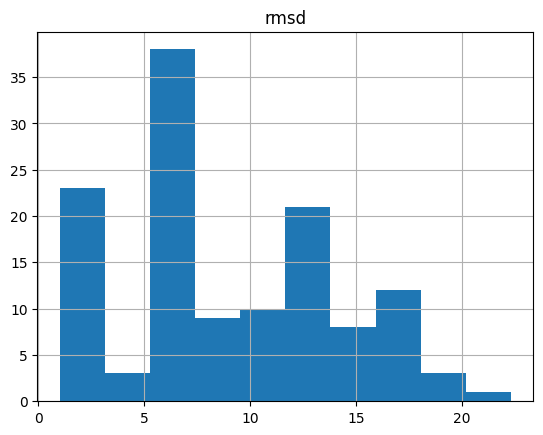

In [167]:
results.hist('rmsd')

array([[<Axes: title={'center': 'i_ptm'}>]], dtype=object)

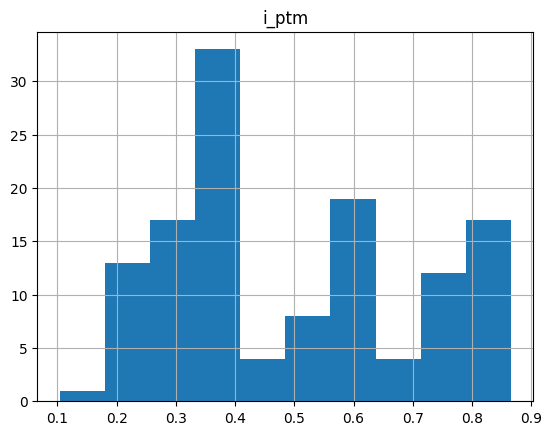

In [168]:
results.hist('i_ptm')

array([[<Axes: title={'center': 'i_pae'}>]], dtype=object)

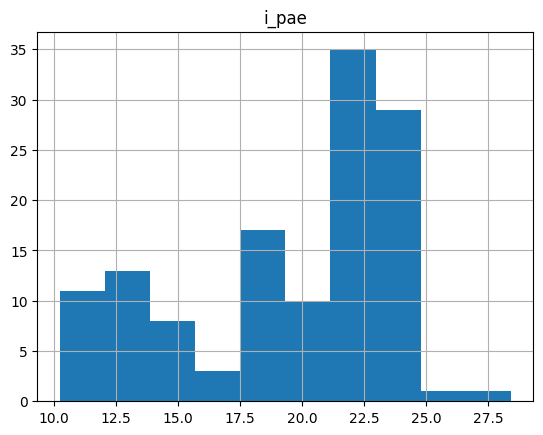

In [169]:
results.hist('i_pae')

In [170]:
# # Filter top sequences by structural confidence
# filtered = results[
#     (results['plddt'] > 0.8) &
#     (results['ptm'] > 0.05) &
#     (results['pae'] < 5.0) &
#     (results['rmsd'] < 2.0)
# ].sort_values(by='plddt', ascending=False)

# print(filtered[['seq', 'plddt', 'ptm', 'pae', 'rmsd', 'mpnn']].head(10))


In [171]:
results['epitope'] = results['seq'].apply(lambda x: x.split("/")[1])

In [172]:
results

,Unnamed: 0,design,n,mpnn,plddt,i_ptm,i_pae,rmsd,seq,RUN,epitope
0,0,0,0,1.261094,0.472035,0.588750,18.013046,13.315507,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,DLFAEFLAP
1,1,0,1,1.269793,0.556109,0.704932,15.357858,13.298151,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,DLFAEALAP
2,2,0,2,1.368507,0.390725,0.333405,22.695281,11.075023,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SLFAEFLAP
3,3,0,3,1.295958,0.467612,0.605406,17.839248,5.435535,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,ALFAEFLAP
4,4,0,4,1.273147,0.390725,0.333405,22.695281,11.075023,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SLFAEFLAP
...,...,...,...,...,...,...,...,...,...,...,...
27,27,0,27,0.982422,0.393490,0.239795,24.520631,7.400931,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,LEAEVAAAARL
28,28,0,28,1.032946,0.372144,0.298575,23.567690,7.063237,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,LEGEVAAAARL
29,29,0,29,0.981554,0.372144,0.298575,23.567690,7.063237,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,LEGEVAAAARL
30,30,0,30,0.984984,0.393490,0.239795,24.520631,7.400931,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,LEAEVAAAARL


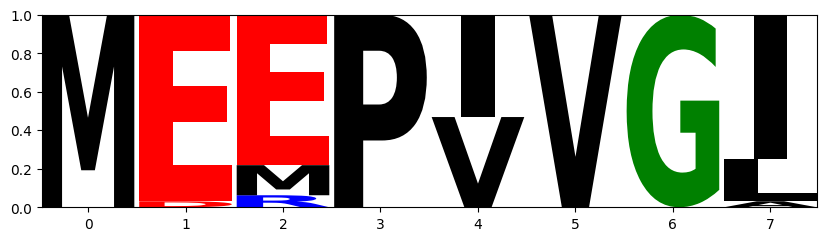

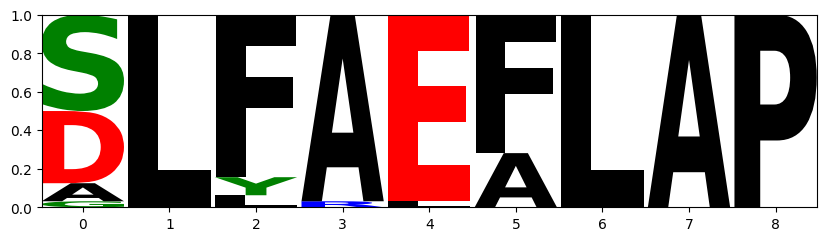

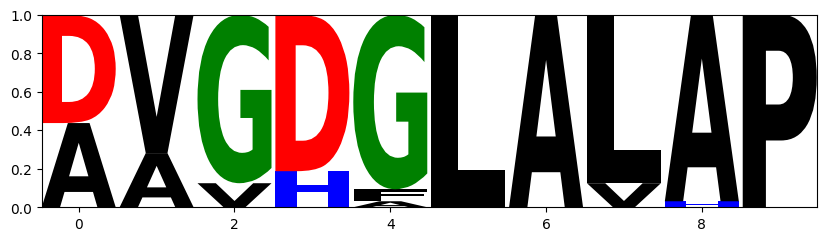

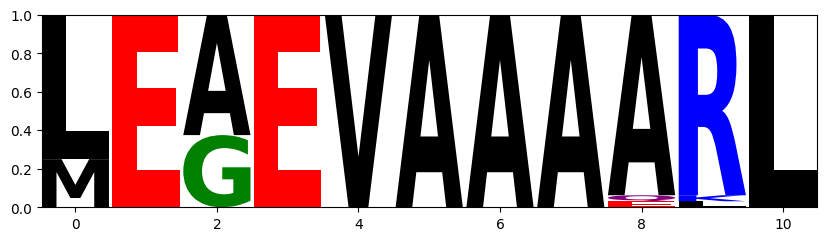

In [176]:
for n in range(8, 12):

    seq_length = n

    sequences = results[results['epitope'].str.len() == seq_length]['epitope'].tolist()

    # Create a list of amino acids (standard 20 amino acids)
    amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

    freq_matrix = np.zeros((seq_length, len(amino_acids)))

    # Populate the frequency matrix: count occurrences of each amino acid at each position
    for seq in sequences:
        for i, aa in enumerate(seq):
            aa_index = amino_acids.index(aa)
            freq_matrix[i, aa_index] += 1

    # Normalize the frequency matrix to get probabilities (frequencies sum to 1 at each position)
    freq_matrix = freq_matrix / len(sequences)

    # Create a DataFrame for logomaker
    freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

    # Generate the sequence logo
    logo = logomaker.Logo(freq_df, color_scheme='chemistry') #, font_name='Arial Rounded MT Bold')
